# 01. 指数・減衰・複素周波数 — s 平面の読み方

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 成長・減衰・振動を $e^{st}$ ひとつにまとめ、$s=\sigma+i\omega$ の位置で時間応答を読む。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture

世の中の「時間変化」の多くは、ごく少数の **指数関数 $e^{st}$** の足し合わせで書けます。
ここで $s = \sigma + i\omega$ は複素数。$\sigma$ が **成長・減衰**、$\omega$ が **振動** を担当します。
ラプラス変換が強力なのは、この $e^{st}$ が微分の **固有関数**(微分しても形が変わらない)だからです。

## 2. Problem — 見かけは違うが同じもの

次の3つは、すべて $e^{st}$ ひとつで書けます。

- **預金**: 年率で増える残高 → $\sigma > 0$ の成長
- **放射性崩壊 / RC 放電**: 一定割合で減る量 → $\sigma < 0$ の減衰
- **おもり付きバネ**: 行ったり来たりする変位 → $\omega \ne 0$ の振動

違うのは $s$ の値だけ。では $s$ をどう読めばよいでしょうか。

## 3. Intuition — 指数は「変化の素」

実指数 $e^{\sigma t}$ は、微分すると $\sigma e^{\sigma t}$。**自分の定数倍に戻る**唯一の関数です。
複素にしても $\frac{d}{dt}e^{st} = s\,e^{st}$。だから線形な系(微分が出てくる系)は、
$e^{st}$ を入れると掛け算 $s$ で応答が決まる。これが「微分 → 掛け算」の正体です。

## 4. Visualization — σ が決める成長と減衰

まず実指数 $e^{\sigma t}$ を、いくつかの $\sigma$ で重ねます。

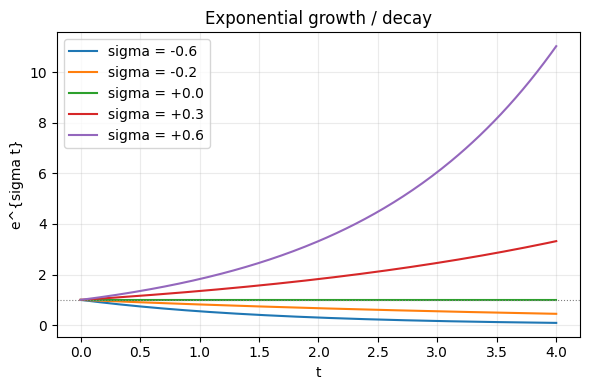

In [2]:
tt = np.linspace(0, 4, 200)
plotting.plot_exponentials(tt, sigmas=[-0.6, -0.2, 0.0, 0.3, 0.6])
plt.tight_layout()

$\sigma<0$ は減衰、$\sigma=0$ は一定、$\sigma>0$ は発散。次に **振動を足した** $e^{\sigma t}\cos(\omega t)$ を、
減衰・持続・成長の3パターンで見ます(点線は包絡線 $\pm e^{\sigma t}$)。

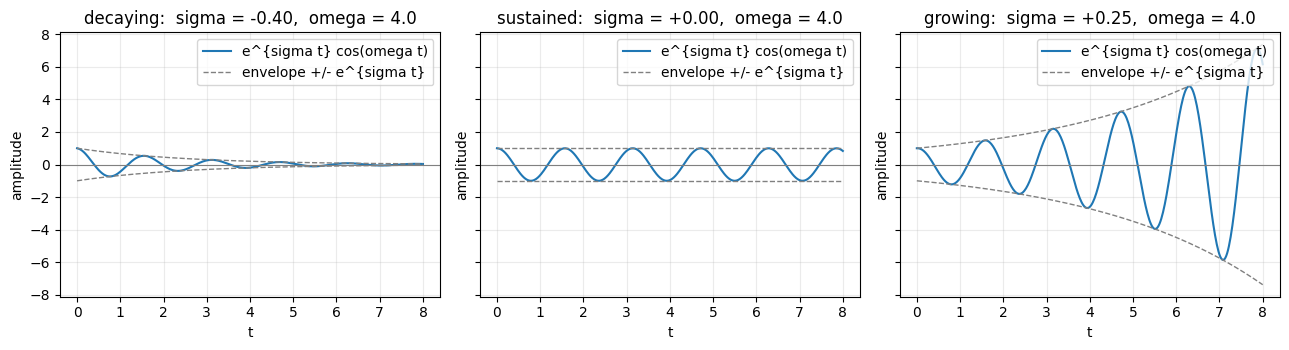

In [3]:
tt = np.linspace(0, 8, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (sig, lab) in zip(axes, [(-0.4, "decaying"), (0.0, "sustained"), (0.25, "growing")]):
    plotting.plot_damped_oscillation(tt, sig, 4.0, ax=ax)
    ax.set_title(f"{lab}:  sigma = {sig:+.2f},  omega = 4.0")
fig.tight_layout()

## 5. Definition — 複素指数と複素周波数

$$ s = \sigma + i\omega, \qquad e^{st} = e^{\sigma t}\,e^{i\omega t} = e^{\sigma t}\big(\cos\omega t + i\sin\omega t\big). $$

- $\sigma = \operatorname{Re}(s)$ : 包絡線 $e^{\sigma t}$ の成長率(負なら減衰)
- $\omega = \operatorname{Im}(s)$ : 振動の角周波数

実数の信号 $e^{\sigma t}\cos(\omega t)$ は、**共役な複素周波数の組** $s = \sigma \pm i\omega$ に対応します。

In [4]:
# Euler's identity and the eigenfunction property, checked numerically.
tt = np.linspace(0, 3, 400)
sigma, omega = -0.4, 4.0
sv = sigma + 1j * omega
lhs = np.exp(sv * tt)
rhs = np.exp(sigma * tt) * (np.cos(omega * tt) + 1j * np.sin(omega * tt))
print("Euler identity, max |lhs - rhs| =", np.max(np.abs(lhs - rhs)))

deriv = np.gradient(lhs, tt)          # numerical d/dt e^{st}
rel = np.max(np.abs(deriv - sv * lhs)) / np.max(np.abs(sv * lhs))
print("eigenfunction d/dt e^{st} = s e^{st}, relative error =", rel)

Euler identity, max |lhs - rhs| = 0.0
eigenfunction d/dt e^{st} = s e^{st}, relative error = 0.015097076657666651


## 6. Computation — s 平面の地図

複素周波数 $s$ を平面の点として描くと、**点の位置がそのまま時間応答の形**になります。
横軸 $\sigma$ が減衰/成長、縦軸 $\omega$ が振動。下は $s=-0.3+3i$(とその共役)の例です。

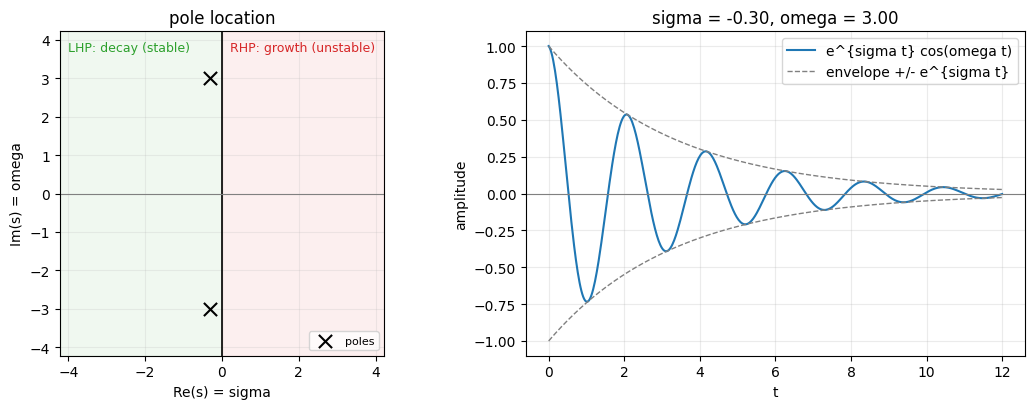

In [5]:
tt = np.linspace(0, 12, 500)
plotting.plot_pole_and_response(sigma=-0.3, omega=3.0, t=tt)
plt.tight_layout()

## 7. Invariant / Structure — なぜこれが効くのか

本質は **$e^{st}$ が $\frac{d}{dt}$ の固有関数** であること。線形時不変な系に $e^{st}$ を入れると、
出てくるのは同じ $e^{st}$ の定数倍。だから複雑な微積分が、$s$ についての代数に化けます。
この一点が、02 章以降の「微分 → 掛け算」「ODE → 代数」「伝達関数」すべての土台です。

## 8. Failure Mode — 成長が速すぎると積分できない (Applied)

ラプラス変換は積分 $\int_0^\infty f(t)e^{-st}dt$。$f$ が速く増えると、$\sigma$ を十分大きく取らないと
積分が発散します(**収束域 ROC**、02 章)。$e^{t^2}$ のように指数より速い増大は、どんな $\sigma$ でも救えません。
下のスライダーで $\sigma, \omega$ を動かし、極の位置と応答が連動する様子を確かめてください
(静的な図は §6 と同じ対象です)。

In [6]:
# Interactive: drag sigma and omega; the pole pair (left) and the response (right) move together.
widgets.explore_complex_frequency()

interactive(children=(FloatSlider(value=-0.4, description='sigma', max=1.0, min=-1.5), FloatSlider(value=3.0, …

<function laplace_book.widgets.explore_complex_frequency.<locals>._draw(sigma=-0.4, omega=3.0)>

## 9. Application

- **人口・複利**: $\sigma>0$ の成長
- **放射性崩壊・冷却・RC 放電**: $\sigma<0$ の減衰
- **LC 共振・振り子**: $\omega\ne0$ の振動、$\sigma$ で減衰の有無

どれも「$s$ をどこに置くか」だけの違いとして統一的に読めます。

## 10. Exercises

- **Basic**: $\sigma=-0.5,\ \omega=2$ の波を手描きし、包絡線と1周期を書き込め。
- **Applied**: `plotting.plot_pole_and_response` を使い、$|s|$ を一定にして角度だけ変え、
  減衰の速さが角度でどう変わるか観察せよ。
- **Advanced**: 半減期 $T_{1/2}$ と $\sigma$ の関係 $\sigma=-\ln 2/T_{1/2}$ を導け。

## 11. Advanced Notes

- **固有関数の厳密化**: 線形時不変作用素 $\mathcal{L}$ に対し $\mathcal{L}e^{st}=H(s)e^{st}$ となる $H(s)$ が
  伝達関数(05 章)。$e^{st}$ は微分作用素の固有関数で、固有値が $s$。
- **特性根との関係**: 定数係数 ODE の特性方程式の根が、まさに $s$ 平面上の極(04・06 章)。
- **物理の複素周波数**: $\sigma$ は減衰率(Q 値)、$\omega$ は固有振動数。両者を1つの $s$ にまとめる見方。